# Imports


In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
# import os
# from google.colab import drive
# from gensim.models import Word2Vec
from textblob import TextBlob
from scipy.sparse import csr_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from wordcloud import WordCloud
from collections import Counter
import string
import nltk
import re
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('stopwords')
nltk.download('omw-1.4')
from sentence_transformers import SentenceTransformer
# import gensim.downloader as api
# import fasttext.util
from sklearn.model_selection import train_test_split

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


# Mounting data and Combining train, test and validation datasets, for splitting later on


In [2]:
from google.colab import drive
import os
# Uncomment to mount Google Drive
drive.mount('/content/drive')

%cd /content/drive/My Drive/BT4222/data
print(os.listdir())

Mounted at /content/drive
/content/drive/My Drive/BT4222/data
['glove.6B.100d.txt', 'train.tsv', 'valid.tsv', 'test.tsv', 'df_with_dates.csv', 'xgboost_predictions.csv', 'bert_predictions.csv', 'df_feature_engineering.parquet', 'lstm_predictions.csv', 'mlp_predictions.csv']


## Read csv file from a directory into pandas DataFrame

In [3]:
# Modify directory if needed
train = pd.read_csv('train.tsv', delimiter = '\t')
valid = pd.read_csv('valid.tsv', delimiter = '\t')
test = pd.read_csv('test.tsv', delimiter = '\t')

In [4]:
# adding column names
column_names = [
    'id', 'label', 'statement', 'subject', 'speaker', 'speaker_job_title', 'state_info',
    'party_affiliation', 'barely_true_counts', 'false_counts', 'half_true_counts',
    'mostly_true_counts', 'pants_on_fire_counts', 'context'
]

train.columns = column_names
valid.columns = column_names
test.columns = column_names

In [5]:
len(train), len(valid), len(test)

(10239, 1283, 1266)

In [ ]:
train.head()

,id,label,statement,subject,speaker,speaker_job_title,state_info,party_affiliation,barely_true_counts,false_counts,half_true_counts,mostly_true_counts,pants_on_fire_counts,context
0,10540.json,half-true,When did the decline of coal start? It started...,"energy,history,job-accomplishments",scott-surovell,State delegate,Virginia,democrat,0.0,0.0,1.0,1.0,0.0,a floor speech.
1,324.json,mostly-true,"Hillary Clinton agrees with John McCain ""by vo...",foreign-policy,barack-obama,President,Illinois,democrat,70.0,71.0,160.0,163.0,9.0,Denver
2,1123.json,false,Health care reform legislation is likely to ma...,health-care,blog-posting,NaN,NaN,none,7.0,19.0,3.0,5.0,44.0,a news release
3,9028.json,half-true,The economic turnaround started at the end of ...,"economy,jobs",charlie-crist,NaN,Florida,democrat,15.0,9.0,20.0,19.0,2.0,an interview on CNN
4,12465.json,true,The Chicago Bears have had more starting quart...,education,robin-vos,Wisconsin Assembly speaker,Wisconsin,republican,0.0,3.0,2.0,5.0,1.0,a an online opinion-piece


In [ ]:
valid.head()

,id,label,statement,subject,speaker,speaker_job_title,state_info,party_affiliation,barely_true_counts,false_counts,half_true_counts,mostly_true_counts,pants_on_fire_counts,context
0,238.json,pants-fire,"When Obama was sworn into office, he DID NOT u...","obama-birth-certificate,religion",chain-email,NaN,NaN,none,11,43,8,5,105,NaN
1,7891.json,false,Says Having organizations parading as being so...,"campaign-finance,congress,taxes",earl-blumenauer,U.S. representative,Oregon,democrat,0,1,1,1,0,a U.S. Ways and Means hearing
2,8169.json,half-true,Says nearly half of Oregons children are poor.,poverty,jim-francesconi,Member of the State Board of Higher Education,Oregon,none,0,1,1,1,0,an opinion article
3,929.json,half-true,On attacks by Republicans that various program...,"economy,stimulus",barack-obama,President,Illinois,democrat,70,71,160,163,9,interview with CBS News
4,9416.json,false,Says when armed civilians stop mass shootings ...,guns,jim-rubens,Small business owner,New Hampshire,republican,1,1,0,1,0,"in an interview at gun shop in Hudson, N.H."


In [ ]:
test.head()

,id,label,statement,subject,speaker,speaker_job_title,state_info,party_affiliation,barely_true_counts,false_counts,half_true_counts,mostly_true_counts,pants_on_fire_counts,context
0,11685.json,false,Wisconsin is on pace to double the number of l...,jobs,katrina-shankland,State representative,Wisconsin,democrat,2,1,0,0,0,a news conference
1,11096.json,false,Says John McCain has done nothing to help the ...,"military,veterans,voting-record",donald-trump,President-Elect,New York,republican,63,114,51,37,61,comments on ABC's This Week.
2,5209.json,half-true,Suzanne Bonamici supports a plan that will cut...,"medicare,message-machine-2012,campaign-adverti...",rob-cornilles,consultant,Oregon,republican,1,1,3,1,1,a radio show
3,9524.json,pants-fire,When asked by a reporter whether hes at the ce...,"campaign-finance,legal-issues,campaign-adverti...",state-democratic-party-wisconsin,NaN,Wisconsin,democrat,5,7,2,2,7,a web video
4,5962.json,true,Over the past five years the federal governmen...,"federal-budget,pensions,retirement",brendan-doherty,NaN,Rhode Island,republican,1,2,1,1,0,a campaign website


In [6]:
# combining all data frames
df = pd.concat([train, valid, test], axis=0).reset_index(drop=True)

df.head()

,id,label,statement,subject,speaker,speaker_job_title,state_info,party_affiliation,barely_true_counts,false_counts,half_true_counts,mostly_true_counts,pants_on_fire_counts,context
0,10540.json,half-true,When did the decline of coal start? It started...,"energy,history,job-accomplishments",scott-surovell,State delegate,Virginia,democrat,0.0,0.0,1.0,1.0,0.0,a floor speech.
1,324.json,mostly-true,"Hillary Clinton agrees with John McCain ""by vo...",foreign-policy,barack-obama,President,Illinois,democrat,70.0,71.0,160.0,163.0,9.0,Denver
2,1123.json,false,Health care reform legislation is likely to ma...,health-care,blog-posting,NaN,NaN,none,7.0,19.0,3.0,5.0,44.0,a news release
3,9028.json,half-true,The economic turnaround started at the end of ...,"economy,jobs",charlie-crist,NaN,Florida,democrat,15.0,9.0,20.0,19.0,2.0,an interview on CNN
4,12465.json,true,The Chicago Bears have had more starting quart...,education,robin-vos,Wisconsin Assembly speaker,Wisconsin,republican,0.0,3.0,2.0,5.0,1.0,a an online opinion-piece


###  Merging with df_with_dates (to get dates of when the statement was made)

In [7]:
df_with_dates = pd.read_csv("df_with_dates.csv")
# only retrieve id and date column
df_with_dates = df_with_dates[['id', 'date']]
df_with_dates.head()

,id,date
0,10540.json,2015-02-04
1,324.json,2008-01-30
2,1123.json,2009-08-04
3,9028.json,2014-03-09
4,12465.json,2016-05-26


In [8]:
df = df.copy()
df = pd.merge(df, df_with_dates, on="id", how="inner")
df.head()

,id,label,statement,subject,speaker,speaker_job_title,state_info,party_affiliation,barely_true_counts,false_counts,half_true_counts,mostly_true_counts,pants_on_fire_counts,context,date
0,10540.json,half-true,When did the decline of coal start? It started...,"energy,history,job-accomplishments",scott-surovell,State delegate,Virginia,democrat,0.0,0.0,1.0,1.0,0.0,a floor speech.,2015-02-04
1,324.json,mostly-true,"Hillary Clinton agrees with John McCain ""by vo...",foreign-policy,barack-obama,President,Illinois,democrat,70.0,71.0,160.0,163.0,9.0,Denver,2008-01-30
2,1123.json,false,Health care reform legislation is likely to ma...,health-care,blog-posting,NaN,NaN,none,7.0,19.0,3.0,5.0,44.0,a news release,2009-08-04
3,9028.json,half-true,The economic turnaround started at the end of ...,"economy,jobs",charlie-crist,NaN,Florida,democrat,15.0,9.0,20.0,19.0,2.0,an interview on CNN,2014-03-09
4,12465.json,true,The Chicago Bears have had more starting quart...,education,robin-vos,Wisconsin Assembly speaker,Wisconsin,republican,0.0,3.0,2.0,5.0,1.0,a an online opinion-piece,2016-05-26


# Data Cleaning and EDA



## Remove duplicates

In [ ]:
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

## Check data types and distribution of numerical values

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12788 entries, 0 to 12787
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    12788 non-null  object 
 1   label                 12788 non-null  object 
 2   statement             12788 non-null  object 
 3   subject               12786 non-null  object 
 4   speaker               12786 non-null  object 
 5   speaker_job_title     9221 non-null   object 
 6   state_info            10039 non-null  object 
 7   party_affiliation     12786 non-null  object 
 8   barely_true_counts    12786 non-null  float64
 9   false_counts          12786 non-null  float64
 10  half_true_counts      12786 non-null  float64
 11  mostly_true_counts    12786 non-null  float64
 12  pants_on_fire_counts  12786 non-null  float64
 13  context               12657 non-null  object 
 14  date                  12788 non-null  object 
dtypes: float64(5), obje

In [ ]:
print(df.describe())

       barely_true_counts  false_counts  half_true_counts  mostly_true_counts  \
count        12786.000000  12786.000000      12786.000000        12786.000000   
mean            11.584233     13.359768         17.186454           16.499922   
std             18.979057     24.141933         35.850604           36.168885   
min              0.000000      0.000000          0.000000            0.000000   
25%              0.000000      0.000000          0.000000            0.000000   
50%              2.000000      2.000000          3.000000            3.000000   
75%             12.000000     15.000000         13.000000           12.000000   
max             70.000000    114.000000        160.000000          163.000000   

       pants_on_fire_counts  
count          12786.000000  
mean               6.251447  
std               16.182153  
min                0.000000  
25%                0.000000  
50%                1.000000  
75%                5.000000  
max              105.000000  


## Check for missing values
- drop rows with small number of null
- since speaker_job_title and state_info and context has a larger number of null values, but we still want to use them in our analysis, we input null values with 'unknown'


In [ ]:
print(df.isnull().sum())

id                         0
label                      0
statement                  0
subject                    2
speaker                    2
speaker_job_title       3567
state_info              2749
party_affiliation          2
barely_true_counts         2
false_counts               2
half_true_counts           2
mostly_true_counts         2
pants_on_fire_counts       2
context                  131
date                       0
dtype: int64


In [ ]:
# Dropping rows with small number of nulls
df = df.dropna(subset=['subject', 'speaker', 'party_affiliation',
                       'barely_true_counts', 'false_counts', 'half_true_counts',
                       'mostly_true_counts', 'pants_on_fire_counts'])

# Imputing missing values for speaker_jobs state to 'Unknown'
df.loc[:, 'speaker_job_title'] = df['speaker_job_title'].fillna('unknown')
df.loc[:, 'state_info'] = df['state_info'].fillna('unknown')
df.loc[:, 'context'] = df['context'].fillna('unknown')

In [ ]:
print(df.isnull().sum())
print(df.info())

id                      0
label                   0
statement               0
subject                 0
speaker                 0
speaker_job_title       0
state_info              0
party_affiliation       0
barely_true_counts      0
false_counts            0
half_true_counts        0
mostly_true_counts      0
pants_on_fire_counts    0
context                 0
date                    0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
Int64Index: 12786 entries, 0 to 12787
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    12786 non-null  object 
 1   label                 12786 non-null  object 
 2   statement             12786 non-null  object 
 3   subject               12786 non-null  object 
 4   speaker               12786 non-null  object 
 5   speaker_job_title     12786 non-null  object 
 6   state_info            12786 non-null  object 
 7   party_affiliation     12

In [ ]:
df.to_csv('df_combined.csv', index=False)

## Examining Unique Values in Categorical Features
- to understand how many unique values in each categorical column

In [ ]:
categorical_columns = ['label', 'subject', 'speaker', 'speaker_job_title', 'state_info', 'party_affiliation', 'context']
categorical_uniques_sum = {col: df[col].nunique() for col in categorical_columns}
categorical_uniques_sum

{'label': 6,
 'subject': 4534,
 'speaker': 3308,
 'speaker_job_title': 1356,
 'state_info': 86,
 'party_affiliation': 24,
 'context': 5141}

In [ ]:
categorical_uniques = {col: df[col].unique() for col in categorical_columns}
categorical_uniques

{'label': array(['half-true', 'mostly-true', 'false', 'true', 'barely-true',
        'pants-fire'], dtype=object),
 'subject': array(['energy,history,job-accomplishments', 'foreign-policy',
        'health-care', ..., 'animals,candidates-biography',
        'bipartisanship,congress,foreign-policy,history',
        'environment,government-efficiency'], dtype=object),
 'speaker': array(['scott-surovell', 'barack-obama', 'blog-posting', ...,
        'hugh-fitzsimons', 'menendez-facts', 'mackubin-thomas-owens'],
       dtype=object),
 'speaker_job_title': array(['State delegate', 'President', 'unknown', ...,
        'U.S. Supreme Court Justice', 'Rancher',
        'senior fellow, Foreign Policy Research Institute'], dtype=object),
 'state_info': array(['Virginia', 'Illinois', 'unknown', 'Florida', 'Wisconsin', 'Texas',
        'New Jersey', 'Vermont', 'Massachusetts', 'Maryland',
        'Washington, D.C. ', 'Oregon', 'New York', 'Washington, D.C.',
        'California', 'Missouri', 'Rhode

## Normalising string columns

### through lowering of cases and removing leading and lagging spaces


In [ ]:
def clean_text(text):
    if isinstance(text, str):
        return text.lower().strip()
    return text

In [ ]:
df[df.select_dtypes(include=['object']).columns] = df.select_dtypes(include=['object']).applymap(clean_text)
df.head()

,id,label,statement,subject,speaker,speaker_job_title,state_info,party_affiliation,barely_true_counts,false_counts,half_true_counts,mostly_true_counts,pants_on_fire_counts,context,date
0,10540.json,half-true,when did the decline of coal start? it started...,"energy,history,job-accomplishments",scott-surovell,state delegate,virginia,democrat,0.0,0.0,1.0,1.0,0.0,a floor speech.,2015-02-04
1,324.json,mostly-true,"hillary clinton agrees with john mccain ""by vo...",foreign-policy,barack-obama,president,illinois,democrat,70.0,71.0,160.0,163.0,9.0,denver,2008-01-30
2,1123.json,false,health care reform legislation is likely to ma...,health-care,blog-posting,unknown,unknown,none,7.0,19.0,3.0,5.0,44.0,a news release,2009-08-04
3,9028.json,half-true,the economic turnaround started at the end of ...,"economy,jobs",charlie-crist,unknown,florida,democrat,15.0,9.0,20.0,19.0,2.0,an interview on cnn,2014-03-09
4,12465.json,true,the chicago bears have had more starting quart...,education,robin-vos,wisconsin assembly speaker,wisconsin,republican,0.0,3.0,2.0,5.0,1.0,a an online opinion-piece,2016-05-26


## Removal of punctuation

### For text columns other than 'statement' and 'subject', we remove punctuation as it is not useful and may cause duplicates

### Since there are subjects with puncutation inside e.g. 'foreign-policy', we keep puncuation for subjects

### Since punctuation may be useful in identifying bias and conveys meaning in 'statement', we keep it

In [ ]:
def remove_punctuation(text):
    if isinstance(text, str):
      return text.translate(str.maketrans(string.punctuation, ' ' * len(string.punctuation)))
    return text

In [ ]:
# Apply to specific columns
cols_to_clean = ['speaker', 'speaker_job_title', 'state_info', 'party_affiliation', 'context']
df[cols_to_clean] = df[cols_to_clean].applymap(remove_punctuation)
df.head()

,id,label,statement,subject,speaker,speaker_job_title,state_info,party_affiliation,barely_true_counts,false_counts,half_true_counts,mostly_true_counts,pants_on_fire_counts,context,date
0,10540.json,half-true,when did the decline of coal start? it started...,"energy,history,job-accomplishments",scott surovell,state delegate,virginia,democrat,0.0,0.0,1.0,1.0,0.0,a floor speech,2015-02-04
1,324.json,mostly-true,"hillary clinton agrees with john mccain ""by vo...",foreign-policy,barack obama,president,illinois,democrat,70.0,71.0,160.0,163.0,9.0,denver,2008-01-30
2,1123.json,false,health care reform legislation is likely to ma...,health-care,blog posting,unknown,unknown,none,7.0,19.0,3.0,5.0,44.0,a news release,2009-08-04
3,9028.json,half-true,the economic turnaround started at the end of ...,"economy,jobs",charlie crist,unknown,florida,democrat,15.0,9.0,20.0,19.0,2.0,an interview on cnn,2014-03-09
4,12465.json,true,the chicago bears have had more starting quart...,education,robin vos,wisconsin assembly speaker,wisconsin,republican,0.0,3.0,2.0,5.0,1.0,a an online opinion piece,2016-05-26


## Processing for 'statement' column

### lowercasing and removal of spaces were already conducted

###  here, we process the statement through: tokenization, removal of stopwords, lemmatization

In [ ]:
def process_text(text):
    # Tokenization (by breaking the text into words)
    tokens = word_tokenize(text)

    # Filter Alphabetic Tokens
    alphabetic_tokens = [word for word in tokens if re.match('^[a-zA-Z]+$', word)]

    # Remove Stopwords and Negation Words
    stop_words = set(stopwords.words('english'))

    # Add 'ha' and 'wa' to stopwords
    stop_words.update(['ha', 'wa'])

    # Negation words that should not be removed
    negation_words = ['not', 'no', 'never', "n't", "isn't", "aren't", "wasn't", "weren't", "hasn't", "haven't",
                      "doesn't", "don't", "didn't", "won't", "wouldn't", "shan't", "shouldn't", "mustn't", "can't", "cannot"]

    # Create a list of tokens without stopwords and preserving negation words
    tokens_no_stopwords = [word for word in alphabetic_tokens if ((word not in stop_words) or (word in negation_words))]

    # Lemmatization
    lemmatizer = WordNetLemmatizer()
    # Apply lemmatization to each token
    lemmatized_words = [lemmatizer.lemmatize(word) for word in tokens_no_stopwords]

    # Join the lemmatized tokens into a single processed text
    processed_text = ' '.join(lemmatized_words)

    return processed_text

In [ ]:
df['statement'] = df['statement'].map(process_text)
df.head()

,id,label,statement,subject,speaker,speaker_job_title,state_info,party_affiliation,barely_true_counts,false_counts,half_true_counts,mostly_true_counts,pants_on_fire_counts,context,date
0,10540.json,half-true,decline coal start started natural gas took st...,"energy,history,job-accomplishments",scott surovell,state delegate,virginia,democrat,0.0,0.0,1.0,1.0,0.0,a floor speech,2015-02-04
1,324.json,mostly-true,hillary clinton agrees john mccain voting give...,foreign-policy,barack obama,president,illinois,democrat,70.0,71.0,160.0,163.0,9.0,denver,2008-01-30
2,1123.json,false,health care reform legislation likely mandate ...,health-care,blog posting,unknown,unknown,none,7.0,19.0,3.0,5.0,44.0,a news release,2009-08-04
3,9028.json,half-true,economic turnaround started end term,"economy,jobs",charlie crist,unknown,florida,democrat,15.0,9.0,20.0,19.0,2.0,an interview on cnn,2014-03-09
4,12465.json,true,chicago bear starting quarterback last year to...,education,robin vos,wisconsin assembly speaker,wisconsin,republican,0.0,3.0,2.0,5.0,1.0,a an online opinion piece,2016-05-26


## One-hot encoding for the 'label' column
### Examining the unique values for the label column, there are 6 unique values: 'half-true', 'mostly-true', 'false', 'true', 'barely-true','pants-fire'.

### However, there is no 'true_count' column in the dataset. Therefore, we use one-hot encoding to take into account the statements which has the label 'true'

In [ ]:
label_dummies = pd.get_dummies(df['label'], prefix='label')
df = pd.concat([df, label_dummies], axis=1)

df.head()

,id,label,statement,subject,speaker,speaker_job_title,state_info,party_affiliation,barely_true_counts,false_counts,...,half_true_counts_cumulative,mostly_true_counts_cumulative,pants_fire_counts_cumulative,true_counts_cumulative,label_barely-true,label_false,label_half-true,label_mostly-true,label_pants-fire,label_true
0,7874.json,half-true,new jersey pension system solvent,"pensions,state-finances",13th district gop slate,unknown,new jersey,republican,0.0,0.0,...,1,0,0,0,0,0,1,0,0,0
1,13412.json,true,test share fact widget,technology,18 percent american public,unknown,unknown,none,0.0,0.0,...,0,0,0,1,0,0,0,0,0,1
2,2287.json,pants-fire,president obama muslim,"candidates-biography,obama-birth-certificate,r...",18 percent american public,unknown,unknown,none,0.0,0.0,...,0,0,1,1,0,0,0,0,1,0
3,2426.json,barely-true,new health care law cut billion medicare hurt ...,"health-care,medicare,message-machine",60 plus association,unknown,unknown,none,2.0,0.0,...,0,0,0,0,1,0,0,0,0,0
4,4832.json,pants-fire,independent payment advisory board created hea...,"government-regulation,health-care,message-mach...",60 plus association,unknown,unknown,none,2.0,0.0,...,0,0,1,0,0,0,0,0,1,0


## Cleaning up the 'party_affiliation' column

## We keep major parties such as republican and democrat and group other categories into broader categories e.g. journalist, columnnist or talk show host to media

In [ ]:
df['party_affiliation'].value_counts()

republican                      5662
democrat                        4137
none                            2181
organization                     264
independent                      180
newsmaker                         64
libertarian                       51
journalist                        49
activist                          45
columnist                         44
talk show host                    32
state official                    24
labor leader                      15
business leader                   11
tea party member                  10
education official                 3
constitution party                 3
green                              3
county commissioner                2
government body                    2
moderate                           1
liberal party canada               1
ocean state tea party action       1
democratic farmer labor            1
Name: party_affiliation, dtype: int64

In [ ]:
# consolidating party affiliations

def simplify_party(party):
    if not isinstance(party, str):
        return "other"

    party = party.lower()

    if party in ["republican", "democrat", "independent", "libertarian", "green", "constitution-party"]:
        return party
    elif "tea-party" in party or "ocean-state-tea-party-action" in party:
        return "tea-party"
    elif "journalist" in party or "columnist" in party or "talk-show-host" in party:
        return "media"
    elif "organization" in party or "government-body" in party:
        return "organization"
    elif "activist" in party or "labor-leader" in party:
        return "activist"
    elif "business-leader" in party:
        return "business"
    elif "education-official" in party:
        return "education"
    else:
        return "other"

df["party_affiliation"] = df["party_affiliation"].apply(simplify_party)
df['party_affiliation'].value_counts()
# one hot encoding for ml models and label encoding for trees?

republican      5662
democrat        4137
other           2351
organization     264
independent      180
media             93
libertarian       51
activist          45
green              3
Name: party_affiliation, dtype: int64

## Cleaning up the 'state_info' column

### We make sure that the same states are labelled the same way and grouped irrelevant states such as 'Qatar' under 'foreign'

In [ ]:
print(df['state_info'].value_counts().to_string())

unknown                                              2750
texas                                                1258
florida                                              1237
wisconsin                                             902
new york                                              831
illinois                                              695
ohio                                                  589
georgia                                               553
virginia                                              513
rhode island                                          454
oregon                                                310
new jersey                                            305
massachusetts                                         256
arizona                                               228
california                                            184
washington  d c                                       156
vermont                                               117
pennsylvania  

In [ ]:
valid_states = {
    'alabama', 'alaska', 'arizona', 'arkansas', 'california', 'colorado', 'connecticut', 'delaware',
    'florida', 'georgia', 'hawaii', 'idaho', 'illinois', 'indiana', 'iowa', 'kansas', 'kentucky',
    'louisiana', 'maine', 'maryland', 'massachusetts', 'michigan', 'minnesota', 'mississippi',
    'missouri', 'montana', 'nebraska', 'nevada', 'new hampshire', 'new jersey', 'new mexico',
    'new york', 'north carolina', 'north dakota', 'ohio', 'oklahoma', 'oregon', 'pennsylvania',
    'rhode island', 'south carolina', 'south dakota', 'tennessee', 'texas', 'utah', 'vermont',
    'virginia', 'washington', 'west virginia', 'wisconsin', 'wyoming', 'district of columbia',
    'unknown'
}

state_corrections = {
    'washington, d.c.': 'district of columbia',
    'washington dc': 'district of columbia',
    'washington d.c.': 'district of columbia',
    'washington  d c': 'district of columbia',
    'washington d c': 'district of columbia',
    'massachusetts ': 'massachusetts',
    'washington state': 'washington',
    'virgina': 'virginia',
    'virgiia': 'virginia',
    'tennesse': 'tennessee',
    'tex': 'texas',
    'pa - pennsylvania': 'pennsylvania',
    'pa   pennsylvania': 'pennsylvania',
    'the united states': 'usa',
    'atlanta': 'georgia'
}

df['state_info'] = df['state_info'].replace(state_corrections)
df = df[df['state_info'] != "virginia director, coalition to stop gun violence"]

# Group non-US states into "foreign"
df['state_info'] = df['state_info'].apply(lambda x: x if x in valid_states else 'foreign')

print(df['state_info'].value_counts().to_string())

unknown                 2750
texas                   1259
florida                 1237
wisconsin                902
new york                 831
illinois                 695
ohio                     589
georgia                  554
virginia                 517
rhode island             454
oregon                   310
new jersey               305
massachusetts            256
arizona                  228
california               184
foreign                  168
vermont                  117
pennsylvania             113
new hampshire            108
arkansas                 103
kentucky                  98
tennessee                 89
maryland                  86
delaware                  84
alaska                    81
minnesota                 75
north carolina            72
nevada                    58
indiana                   52
missouri                  48
south carolina            39
new mexico                37
louisiana                 33
colorado                  33
michigan      

In [ ]:
# Number of unique values in 'state_info'
num_unique_states = df['state_info'].nunique()
print(f"Number of unique values in 'state_info': {num_unique_states}")

# Unique values in 'state_info'
unique_states = df['state_info'].unique()
print("Unique values in 'state_info':")
print(unique_states)

Number of unique values in 'state_info': 53
Unique values in 'state_info':
['new jersey' 'unknown' 'rhode island' 'florida' 'north carolina'
 'illinois' 'texas' 'new york' 'foreign' 'tennessee' 'oregon' 'georgia'
 'wyoming' 'wisconsin' 'virginia' 'arizona' 'kentucky' 'california' 'ohio'
 'minnesota' 'new hampshire' 'pennsylvania' 'alabama' 'massachusetts'
 'michigan' 'maryland' 'nebraska' 'vermont' 'district of columbia'
 'louisiana' 'arkansas' 'new mexico' 'west virginia' 'hawaii' 'montana'
 'iowa' 'missouri' 'nevada' 'washington' 'kansas' 'indiana' 'delaware'
 'connecticut' 'colorado' 'oklahoma' 'alaska' 'south carolina'
 'mississippi' 'utah' 'south dakota' 'north dakota' 'maine' 'idaho']


# Visualisations

## Checking label distribution:
- This helps use to understand class imbalance and whether there is a need for resampling techniques

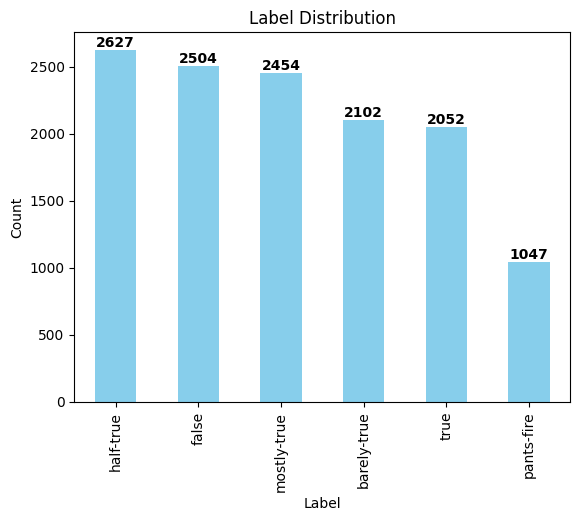

In [ ]:
ax = df['label'].value_counts().plot(kind='bar', color='skyblue')

plt.title('Label Distribution')
plt.xlabel('Label')
plt.ylabel('Count')

# Add count labels on top of each bar
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.show()

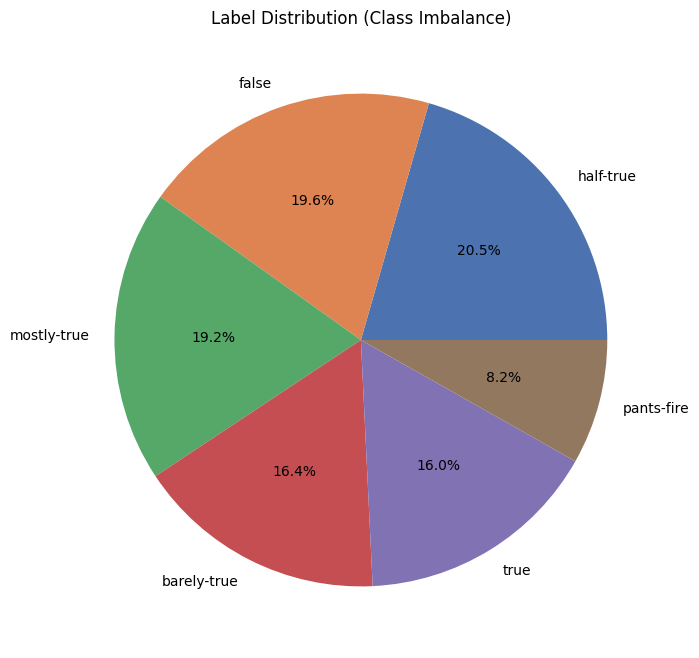

In [ ]:
# Visualize label distribution (for classification)
plt.figure(figsize=(8, 8))
colors = sns.color_palette('deep')[0:6]
df['label'].value_counts().plot(kind='pie', colors = colors, autopct='%1.1f%%')

plt.title('Label Distribution (Class Imbalance)')
plt.ylabel('')
plt.show()

### The class distribution of the label look fairly balanced

## Check subject(s) distribution

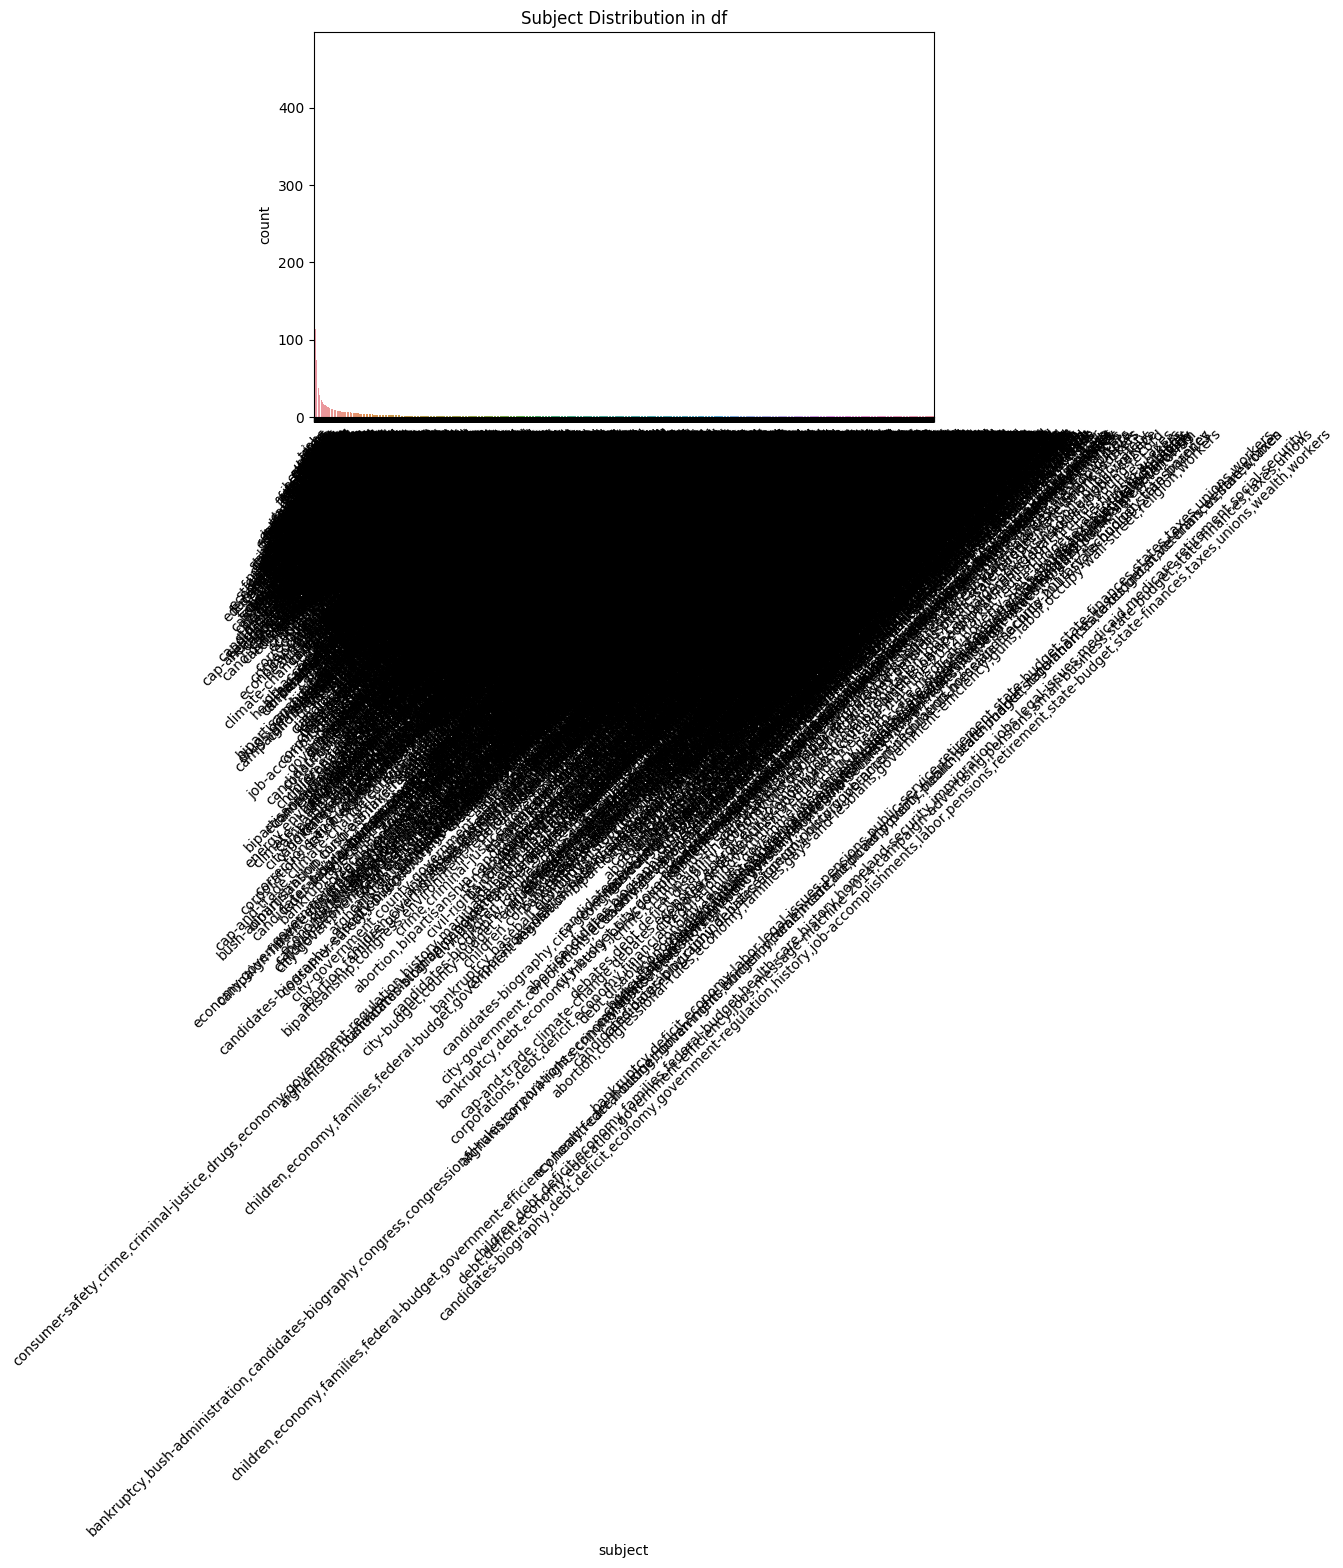

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="subject", order=df["subject"].value_counts().index)
plt.title("Subject Distribution in df")
plt.xticks(rotation=45)
plt.show()

### only show top 20 subjects

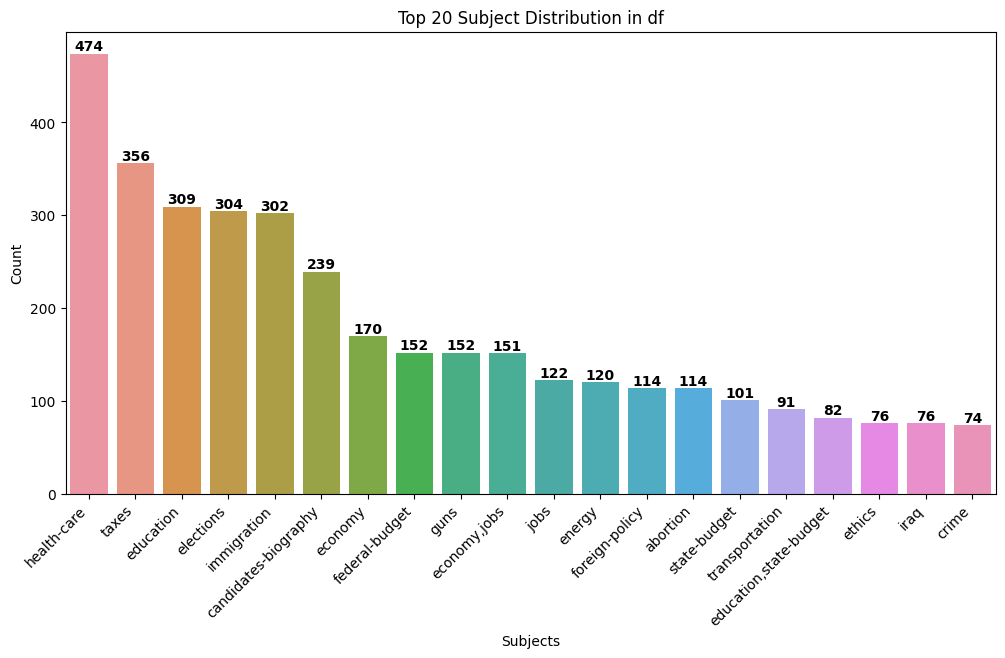

In [ ]:
plt.figure(figsize=(12, 6))
ax = sns.countplot(data=df, x="subject", order=df["subject"].value_counts().nlargest(20).index)

plt.title("Top 20 Subject Distribution in df")
plt.xticks(rotation=45, ha="right")
plt.xlabel("Subjects")
plt.ylabel("Count")

# Add count labels on bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10, color='black', weight='bold')

plt.show()

## Check Speaker Distribution

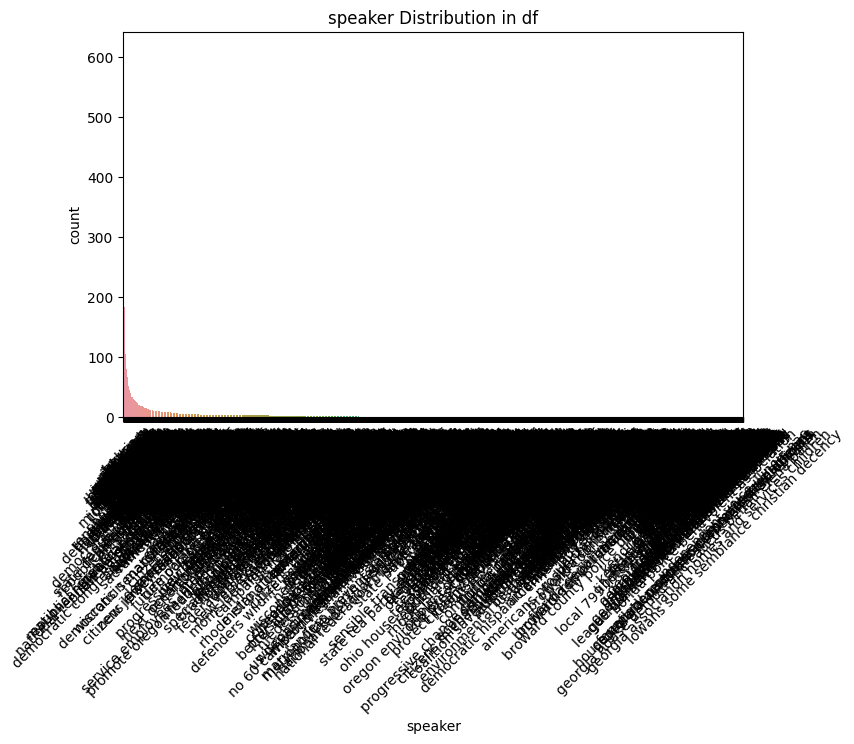

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="speaker", order=df["speaker"].value_counts().index)
plt.title("speaker Distribution in df")
plt.xticks(rotation=45)

plt.show()

### Top 20 speakers

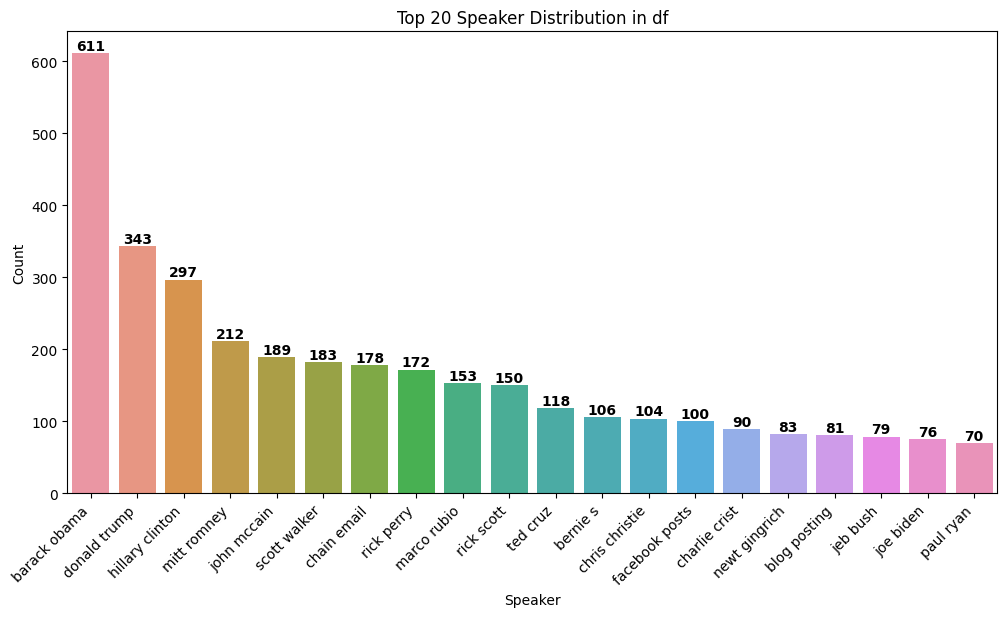

In [ ]:
plt.figure(figsize=(12, 6))
ax = sns.countplot(data=df, x="speaker", order=df["speaker"].value_counts().nlargest(20).index)

plt.title("Top 20 Speaker Distribution in df")
plt.xticks(rotation=45, ha="right")
plt.xlabel("Speaker")
plt.ylabel("Count")

# Add count labels on bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10, color='black', weight='bold')

plt.show()

### Visualise the distribution of labels for the statements made by each speaker



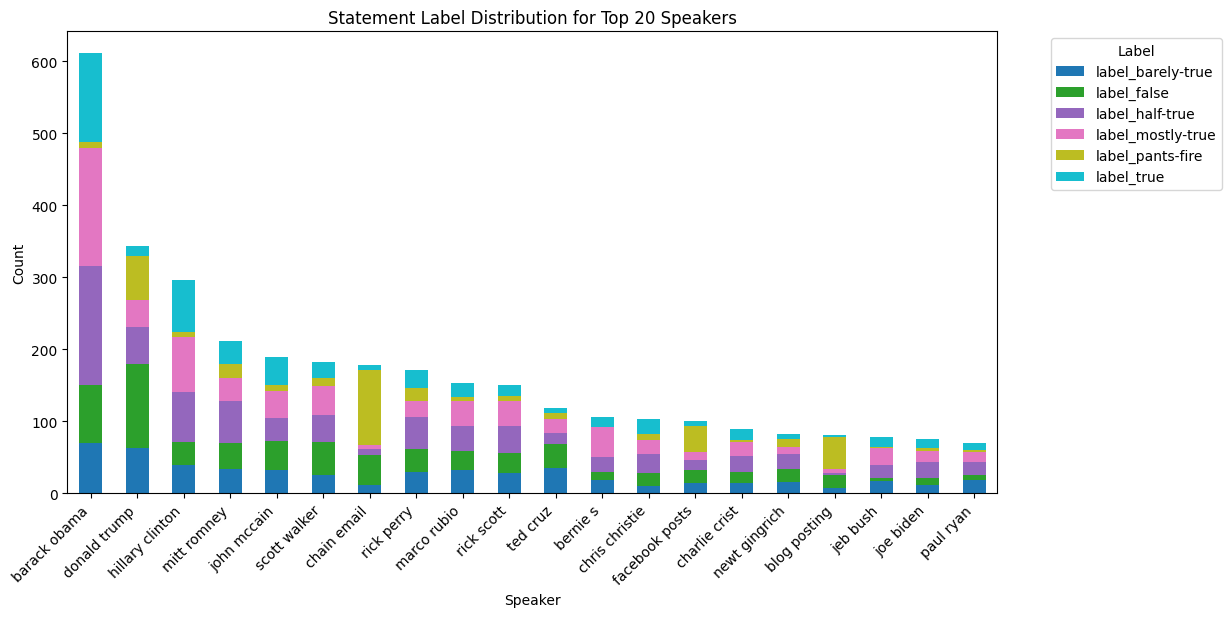

In [ ]:
# Get the top 20 speakers by count
top_20_speakers = df["speaker"].value_counts().nlargest(20).index

# Filter the dataset to only include these speakers
df_top_speakers = df[df["speaker"].isin(top_20_speakers)]

# Aggregate the label counts for each speaker
label_columns = ["label_barely-true", "label_false", "label_half-true", "label_mostly-true", "label_pants-fire", "label_true"]
df_speaker_labels = df_top_speakers.groupby("speaker")[label_columns].sum()

# Order speakers by total statement count in descending order
df_speaker_labels["total_statements"] = df_speaker_labels.sum(axis=1)
df_speaker_labels = df_speaker_labels.sort_values(by="total_statements", ascending=False).drop(columns=["total_statements"])

# Plot stacked bar chart
df_speaker_labels.plot(kind="bar", stacked=True, figsize=(12, 6), colormap="tab10")

plt.title("Statement Label Distribution for Top 20 Speakers")
plt.xlabel("Speaker")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Label", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.show()

### Out of the top 20 speakers, we visualise the top 5 speakers with "True" statements and "False statements" (in terms of percentage)

In [ ]:
# Compute percentages for "true" and "false" statements
df_speaker_labels["true_percentage"] = df_speaker_labels["label_true"] / df_speaker_labels.sum(axis=1) * 100
df_speaker_labels["false_percentage"] = df_speaker_labels["label_false"] / df_speaker_labels.sum(axis=1) * 100

# Get top 5 speakers with the highest percentage of "true" statements
top_5_true_speakers = df_speaker_labels.nlargest(5, "true_percentage")[["true_percentage", "label_true"]]

# Get top 5 speakers with the highest percentage of "false" statements
top_5_false_speakers = df_speaker_labels.nlargest(5, "false_percentage")[["false_percentage", "label_false"]]

# Function to retrieve additional speaker details
def get_speaker_details(df, speakers):
    return df[df["speaker"].isin(speakers)].groupby("speaker").first()[["speaker_job_title", "state_info", "party_affiliation"]]

# Merge with speaker details
top_5_true_speakers = top_5_true_speakers.merge(get_speaker_details(df, top_5_true_speakers.index), left_index=True, right_index=True)
top_5_false_speakers = top_5_false_speakers.merge(get_speaker_details(df, top_5_false_speakers.index), left_index=True, right_index=True)

# Display results
print("Top 5 Speakers with the Highest Percentage of 'True' Statements:")
top_5_true_speakers

Top 5 Speakers with the Highest Percentage of 'True' Statements:


,true_percentage,label_true,speaker_job_title,state_info,party_affiliation
speaker,,,,,
hillary clinton,24.579125,73,presidential candidate,new york,democrat
chris christie,21.153846,22,governor of new jersey,new jersey,republican
john mccain,20.634921,39,u s senator,arizona,republican
barack obama,20.130933,123,president,illinois,democrat
charlie crist,17.777778,16,unknown,florida,democrat


In [ ]:
print("\nTop 5 Speakers with the Highest Percentage of 'False' Statements:")
top_5_false_speakers


Top 5 Speakers with the Highest Percentage of 'False' Statements:


,false_percentage,label_false,speaker_job_title,state_info,party_affiliation
speaker,,,,,
donald trump,33.709649,117,president elect,new york,republican
ted cruz,27.434354,34,senator,texas,republican
scott walker,24.032524,47,milwaukee county executive,wisconsin,republican
chain email,23.708338,43,unknown,unknown,other
blog posting,22.431132,19,unknown,unknown,other


## Check job title distribution

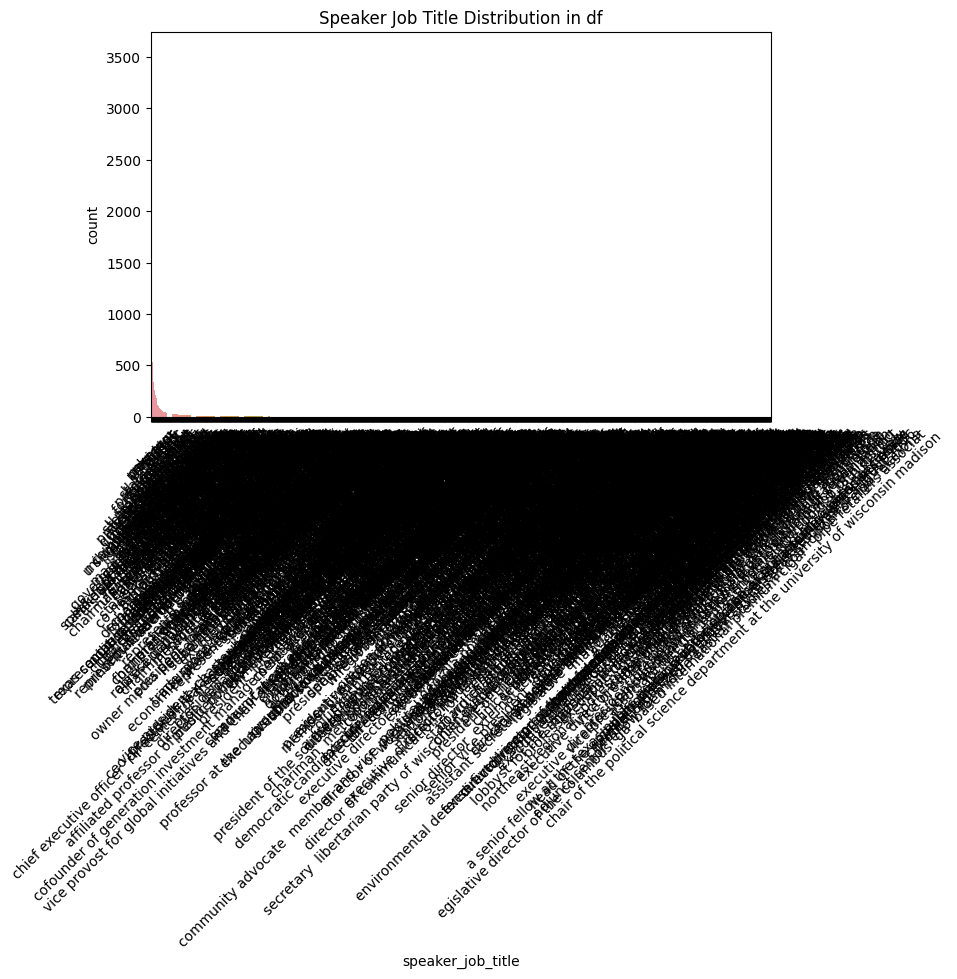

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="speaker_job_title", order=df["speaker_job_title"].value_counts().index)
plt.title("Speaker Job Title Distribution in df")
plt.xticks(rotation=45)

plt.show()

### show top 20 job title distributions

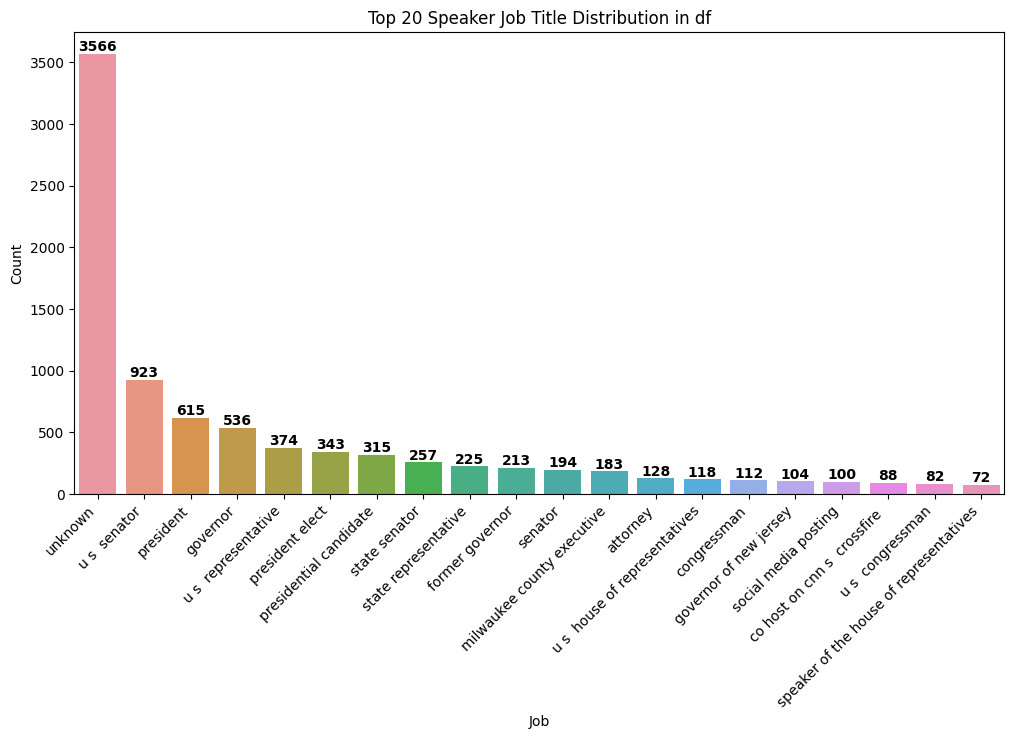

In [ ]:
plt.figure(figsize=(12, 6))
ax = sns.countplot(data=df, x="speaker_job_title", order=df["speaker_job_title"].value_counts().nlargest(20).index)

plt.title("Top 20 Speaker Job Title Distribution in df")
plt.xticks(rotation=45, ha="right")
plt.xlabel("Job")
plt.ylabel("Count")

# Add count labels on bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10, color='black', weight='bold')

plt.show()

## Check state info distribution

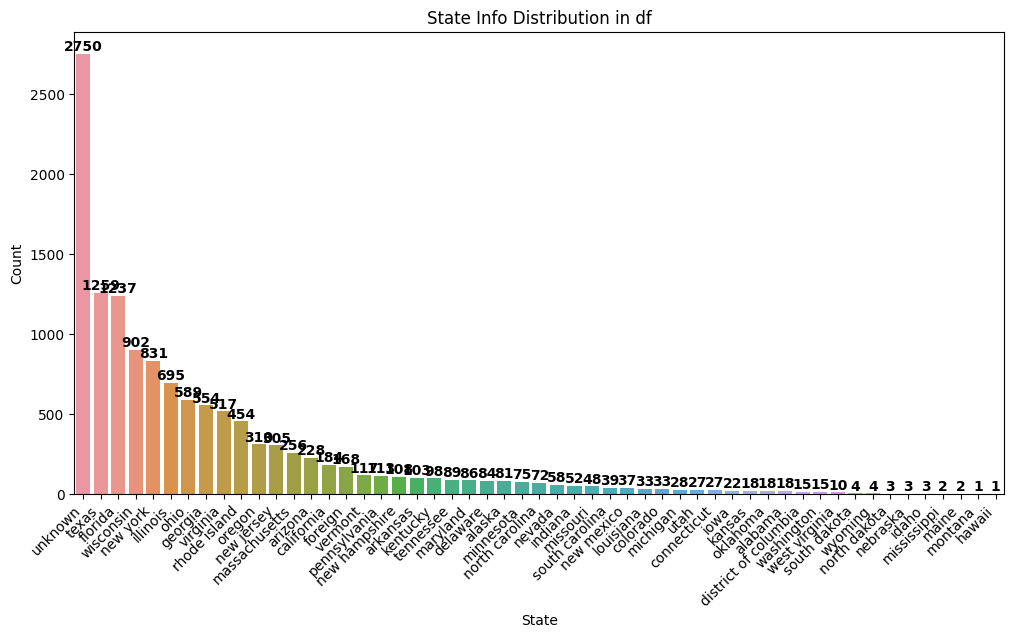

In [ ]:
plt.figure(figsize=(12, 6))
ax = sns.countplot(data=df, x="state_info", order=df["state_info"].value_counts().index)

plt.title("State Info Distribution in df")
plt.xticks(rotation=45, ha="right")
plt.xlabel("State")
plt.ylabel("Count")

# Add count labels on bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10, color='black', weight='bold')

plt.show()

## Check party affliation distribution

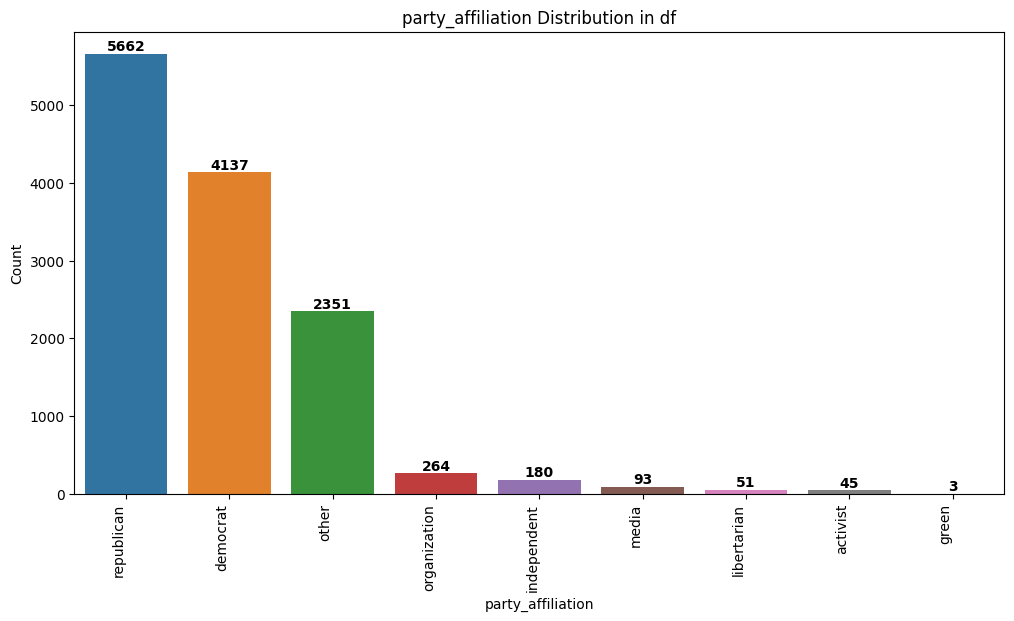

In [ ]:
plt.figure(figsize=(12, 6))

# Order states in descending count order
order = df["party_affiliation"].value_counts().index

# Create count plot
ax = sns.countplot(data=df, x="party_affiliation", order=order)

# Add count labels on bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10, color='black', weight='bold')

# Adjust title and labels
plt.title("party_affiliation Distribution in df", fontsize=12)
plt.xticks(rotation=90, ha="right")
plt.ylabel("Count")

# Show the plot
plt.show()

## Check context distribution

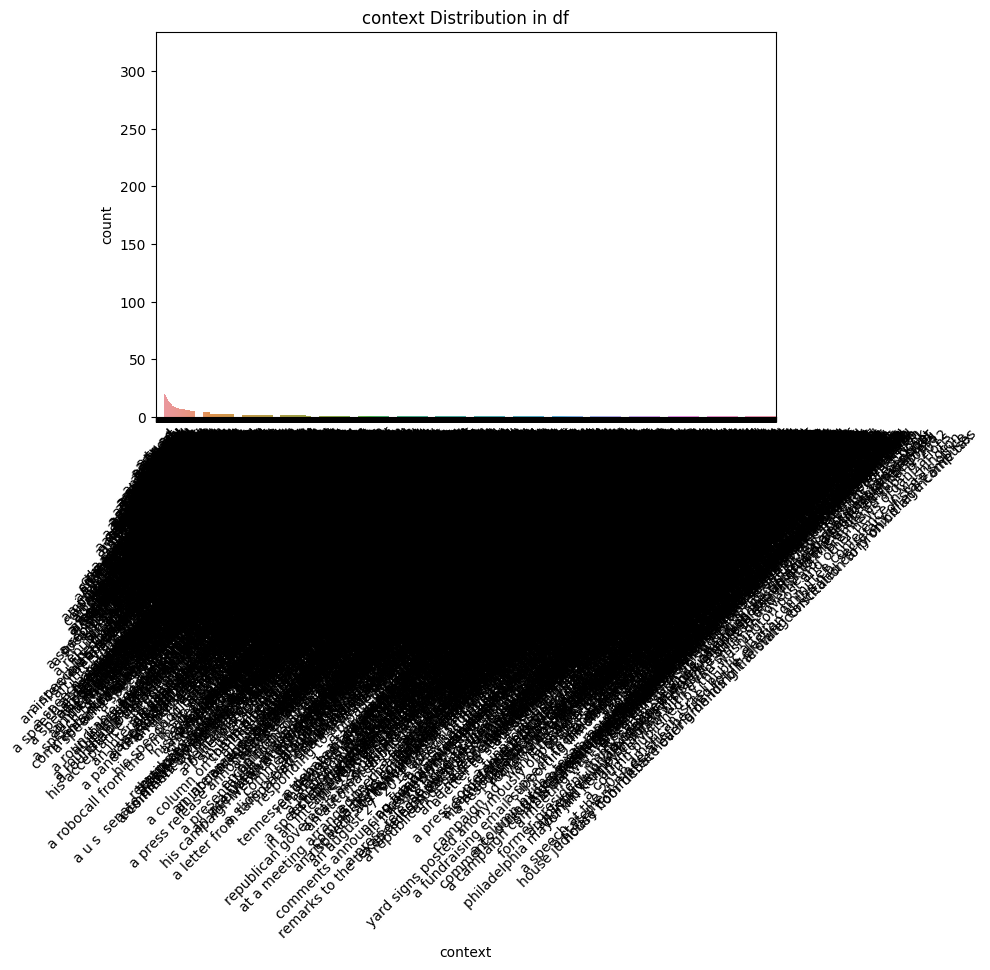

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="context", order=df["context"].value_counts().index)
plt.title("context Distribution in df")
plt.xticks(rotation=45)
plt.show()

## Check average length of 'Statement'

In [ ]:
# number of words in statement
df['statement_word_count'] = df['statement'].apply(lambda x: len(str(x).split()))

# average number of words in the 'statement' column
average_word_count = df['statement_word_count'].mean()
print(f"Average number of words in statement column: {average_word_count}")


Average number of words in statement column: 10.36055060222118


### Statement length for each label

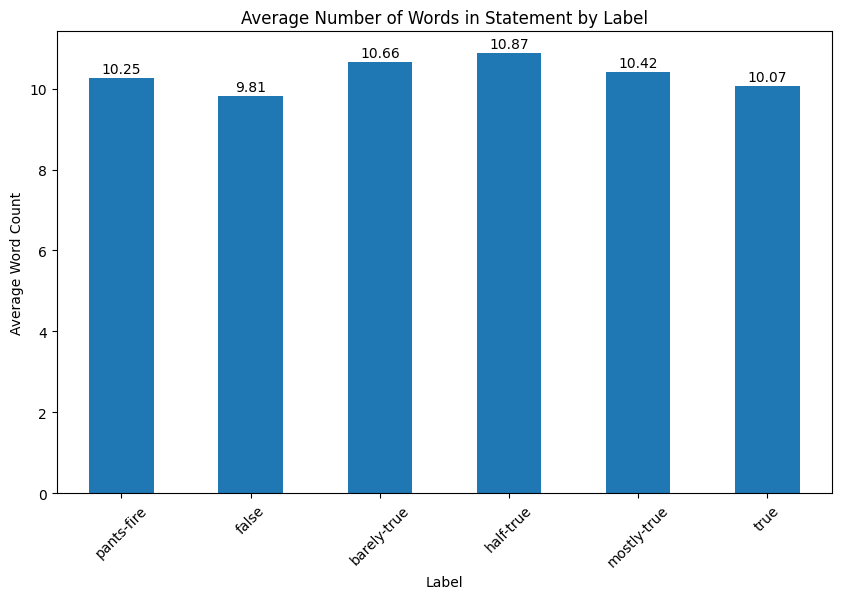

In [ ]:
custom_order = ['pants-fire', 'false', 'barely-true', 'half-true', 'mostly-true', 'true']

# group by 'label'
avg_words_by_label = df.groupby('label')['statement_word_count'].mean().round(2)
# reindex
avg_words_by_label = avg_words_by_label.reindex(custom_order)

# plot the average number of words for each label
ax = avg_words_by_label.plot(kind='bar', figsize=(10, 6))

for i, v in enumerate(avg_words_by_label):
    ax.text(i, v + 0.05, str(v), ha='center', va='bottom', fontsize=10)

plt.title('Average Number of Words in Statement by Label')
plt.xlabel('Label')
plt.ylabel('Average Word Count')
plt.xticks(rotation=45)
plt.show()

## Word cloud for each label

In [ ]:
labels = df['label'].unique()

for label in labels:
    # Filter the data for the current label
    text = ' '.join(df[df['label'] == label]['statement'])

    # Create a WordCloud object
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

    # Plot the WordCloud for the current label
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Word Cloud for Label: {label}')
    plt.show()

Output hidden; open in https://colab.research.google.com to view.

# Feature Engineering (No need to run, can just open parquet file)
- 'statement': sentence embeddings
- 'subject': average of word embeddings
- 'speaker_job_title': named entity recognition
- 'context': word embeddings

## Checking updated values of features

In [ ]:
categorical_columns = ['label', 'subject', 'speaker', 'speaker_job_title', 'state_info', 'party_affiliation', 'context']
categorical_uniques_sum = {col: df[col].nunique() for col in categorical_columns}
categorical_uniques_sum

{'label': 6,
 'subject': 4534,
 'speaker': 3308,
 'speaker_job_title': 1266,
 'state_info': 53,
 'party_affiliation': 9,
 'context': 4944}

In [ ]:
categorical_uniques = {col: df[col].unique() for col in categorical_columns}
categorical_uniques

{'label': array(['half-true', 'true', 'pants-fire', 'barely-true', 'mostly-true',
        'false'], dtype=object),
 'subject': array(['pensions,state-finances', 'technology',
        'candidates-biography,obama-birth-certificate,religion', ...,
        'city-government,civil-rights,crime,criminal-justice,guns,public-safety',
        'poverty,voting-record', 'congress,environment'], dtype=object),
 'speaker': array(['13th district gop slate', '18 percent american public',
        '60 plus association', ..., 'zell miller', 'zephyr teachout',
        'zoe lofgren'], dtype=object),
 'speaker_job_title': array(['unknown', 'program manager  sierra club of rhode island',
        'u s  representative', ..., 'president of china',
        'ohio supreme court justice',
        'former u s  representative from ohio s 18th district'],
       dtype=object),
 'state_info': array(['new jersey', 'unknown', 'rhode island', 'florida',
        'north carolina', 'illinois', 'texas', 'new york', 'foreign',


## 'statement' Feature Engineering
- to ensure that 'statement' is prepared to be fed into neural network models, we use sentence embeddings to get dense representations
- we use the 'all-MiniLM-L6-v2' as it is general purpose and provides a good balance between performance and speed

In [ ]:
# load sentence embeddints for 'statement'
print("Loading SBERT model...")
sbert_model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

Loading SBERT model...


In [ ]:
# apply model to the 'statement' column
def get_sentence_embedding(text):
    return sbert_model.encode(text)

# save embeddings to a new column
df['statement_embedding'] = df['statement'].apply(get_sentence_embedding)

In [ ]:
df.head()

,id,label,statement,subject,speaker,speaker_job_title,state_info,party_affiliation,barely_true_counts,false_counts,...,mostly_true_counts_cumulative,pants_fire_counts_cumulative,true_counts_cumulative,label_barely-true,label_false,label_half-true,label_mostly-true,label_pants-fire,label_true,statement_embedding
0,7874.json,half-true,new jersey pension system solvent,"pensions,state-finances",13th district gop slate,unknown,new jersey,republican,0.0,0.0,...,0,0,0,0,0,1,0,0,0,"[-0.012083505, 0.042914398, -0.07741898, -0.04..."
1,13412.json,true,test share fact widget,technology,18 percent american public,unknown,unknown,other,0.0,0.0,...,0,0,1,0,0,0,0,0,1,"[0.008107001, 0.01603668, -0.03262832, 0.05087..."
2,2287.json,pants-fire,president obama muslim,"candidates-biography,obama-birth-certificate,r...",18 percent american public,unknown,unknown,other,0.0,0.0,...,0,1,1,0,0,0,0,1,0,"[0.038615476, 0.09793296, -0.019909535, 0.0296..."
3,2426.json,barely-true,new health care law cut billion medicare hurt ...,"health-care,medicare,message-machine",60 plus association,unknown,unknown,other,2.0,0.0,...,0,0,0,1,0,0,0,0,0,"[-0.050847925, 0.031769607, 0.035102487, -0.01..."
4,4832.json,pants-fire,independent payment advisory board created hea...,"government-regulation,health-care,message-mach...",60 plus association,unknown,unknown,other,2.0,0.0,...,0,1,0,0,0,0,0,1,0,"[-0.107817285, 0.017993968, 0.00931019, -0.001..."


In [ ]:
first_embedding = df.loc[0, 'statement_embedding']
# Convert to numpy array if it's stored as a list or string
if isinstance(first_embedding, list):
    first_embedding = np.array(first_embedding)
elif isinstance(first_embedding, str):  # If stored as a string, convert it back
    import ast
    first_embedding = np.array(ast.literal_eval(first_embedding))

# Print shape of the embedding
print(f"Embedding shape: {first_embedding.shape}")

embedding_type = type(first_embedding)

print(f"Embedding type: {embedding_type}")

Embedding shape: (384,)
Embedding type: <class 'numpy.ndarray'>


In [ ]:
# Check if the embedding contains numeric data
if np.issubdtype(first_embedding.dtype, np.number):
    print("The embedding contains numeric data.")
else:
    print("The embedding does not contain numeric data.")

The embedding contains numeric data.


## 'subject' Feature Engineering
- use sentence embeddings also as there may be several words in a subject (FastText is unable to)
- sentence transformer will be able to take into context and also account for hyphenated-words (GloVe is unable to)

In [ ]:
# save embeddings to a new column
df['subject_embedding'] = df['subject'].apply(get_sentence_embedding)

In [ ]:
df.head()

,id,label,statement,subject,speaker,speaker_job_title,state_info,party_affiliation,barely_true_counts,false_counts,...,pants_fire_counts_cumulative,true_counts_cumulative,label_barely-true,label_false,label_half-true,label_mostly-true,label_pants-fire,label_true,statement_embedding,subject_embedding
0,7874.json,half-true,new jersey pension system solvent,"pensions,state-finances",13th district gop slate,unknown,new jersey,republican,0.0,0.0,...,0,0,0,0,1,0,0,0,"[-0.012083505, 0.042914398, -0.07741898, -0.04...","[-0.00025620736, 0.073738396, -0.07717613, 0.0..."
1,13412.json,true,test share fact widget,technology,18 percent american public,unknown,unknown,other,0.0,0.0,...,0,1,0,0,0,0,0,1,"[0.008107001, 0.01603668, -0.03262832, 0.05087...","[-0.053375788, 0.08707486, -0.026189229, -0.03..."
2,2287.json,pants-fire,president obama muslim,"candidates-biography,obama-birth-certificate,r...",18 percent american public,unknown,unknown,other,0.0,0.0,...,1,1,0,0,0,0,1,0,"[0.038615476, 0.09793296, -0.019909535, 0.0296...","[0.018359246, -0.002745044, 0.00724984, -0.033..."
3,2426.json,barely-true,new health care law cut billion medicare hurt ...,"health-care,medicare,message-machine",60 plus association,unknown,unknown,other,2.0,0.0,...,0,0,1,0,0,0,0,0,"[-0.050847925, 0.031769607, 0.035102487, -0.01...","[-0.014705911, 0.015529205, 0.021055419, 0.001..."
4,4832.json,pants-fire,independent payment advisory board created hea...,"government-regulation,health-care,message-mach...",60 plus association,unknown,unknown,other,2.0,0.0,...,1,0,0,0,0,0,1,0,"[-0.107817285, 0.017993968, 0.00931019, -0.001...","[0.02528246, 0.005831953, -0.008445839, -0.001..."


## 'state_info' Feature Engineering
- use label encoder as state_info is categorical and there are only 53 unique values

In [ ]:
label_encoder = LabelEncoder()

# encode 'state_info' column and assign it to a new column
df['state_info_encoded'] = label_encoder.fit_transform(df['state_info'])

In [ ]:
df.head()

,id,label,statement,subject,speaker,speaker_job_title,state_info,party_affiliation,barely_true_counts,false_counts,...,true_counts_cumulative,label_barely-true,label_false,label_half-true,label_mostly-true,label_pants-fire,label_true,statement_embedding,subject_embedding,state_info_encoded
0,7874.json,half-true,new jersey pension system solvent,"pensions,state-finances",13th district gop slate,unknown,new jersey,republican,0.0,0.0,...,0,0,0,1,0,0,0,"[-0.012083505, 0.042914398, -0.07741898, -0.04...","[-0.00025620736, 0.073738396, -0.07717613, 0.0...",31
1,13412.json,true,test share fact widget,technology,18 percent american public,unknown,unknown,other,0.0,0.0,...,1,0,0,0,0,0,1,"[0.008107001, 0.01603668, -0.03262832, 0.05087...","[-0.053375788, 0.08707486, -0.026189229, -0.03...",45
2,2287.json,pants-fire,president obama muslim,"candidates-biography,obama-birth-certificate,r...",18 percent american public,unknown,unknown,other,0.0,0.0,...,1,0,0,0,0,1,0,"[0.038615476, 0.09793296, -0.019909535, 0.0296...","[0.018359246, -0.002745044, 0.00724984, -0.033...",45
3,2426.json,barely-true,new health care law cut billion medicare hurt ...,"health-care,medicare,message-machine",60 plus association,unknown,unknown,other,2.0,0.0,...,0,1,0,0,0,0,0,"[-0.050847925, 0.031769607, 0.035102487, -0.01...","[-0.014705911, 0.015529205, 0.021055419, 0.001...",45
4,4832.json,pants-fire,independent payment advisory board created hea...,"government-regulation,health-care,message-mach...",60 plus association,unknown,unknown,other,2.0,0.0,...,0,0,0,0,0,1,0,"[-0.107817285, 0.017993968, 0.00931019, -0.001...","[0.02528246, 0.005831953, -0.008445839, -0.001...",45


## 'party_affiliation' Feature Engineering
- use label encoder as party_affiliaiton is categorical and there are only 9 unique values

In [ ]:
# encode 'party_affiliation' column and assign it to a new column
df['party_affiliation_encoded'] = label_encoder.fit_transform(df['party_affiliation'])

In [ ]:
df.head()

,id,label,statement,subject,speaker,speaker_job_title,state_info,party_affiliation,barely_true_counts,false_counts,...,label_barely-true,label_false,label_half-true,label_mostly-true,label_pants-fire,label_true,statement_embedding,subject_embedding,state_info_encoded,party_affiliation_encoded
0,7874.json,half-true,new jersey pension system solvent,"pensions,state-finances",13th district gop slate,unknown,new jersey,republican,0.0,0.0,...,0,0,1,0,0,0,"[-0.012083505, 0.042914398, -0.07741898, -0.04...","[-0.00025620736, 0.073738396, -0.07717613, 0.0...",31,8
1,13412.json,true,test share fact widget,technology,18 percent american public,unknown,unknown,other,0.0,0.0,...,0,0,0,0,0,1,"[0.008107001, 0.01603668, -0.03262832, 0.05087...","[-0.053375788, 0.08707486, -0.026189229, -0.03...",45,7
2,2287.json,pants-fire,president obama muslim,"candidates-biography,obama-birth-certificate,r...",18 percent american public,unknown,unknown,other,0.0,0.0,...,0,0,0,0,1,0,"[0.038615476, 0.09793296, -0.019909535, 0.0296...","[0.018359246, -0.002745044, 0.00724984, -0.033...",45,7
3,2426.json,barely-true,new health care law cut billion medicare hurt ...,"health-care,medicare,message-machine",60 plus association,unknown,unknown,other,2.0,0.0,...,1,0,0,0,0,0,"[-0.050847925, 0.031769607, 0.035102487, -0.01...","[-0.014705911, 0.015529205, 0.021055419, 0.001...",45,7
4,4832.json,pants-fire,independent payment advisory board created hea...,"government-regulation,health-care,message-mach...",60 plus association,unknown,unknown,other,2.0,0.0,...,0,0,0,0,1,0,"[-0.107817285, 0.017993968, 0.00931019, -0.001...","[0.02528246, 0.005831953, -0.008445839, -0.001...",45,7


## 'speaker_job_title' Feature Engineering
- using the sentence transformer to provide embeddings since some of the column values consist of multiple words

In [ ]:
df['speaker_job_title_embedding'] = df['speaker_job_title'].apply(get_sentence_embedding)

In [ ]:
df.head()

,id,label,statement,subject,speaker,speaker_job_title,state_info,party_affiliation,barely_true_counts,false_counts,...,label_false,label_half-true,label_mostly-true,label_pants-fire,label_true,statement_embedding,subject_embedding,state_info_encoded,party_affiliation_encoded,speaker_job_title_embedding
0,7874.json,half-true,new jersey pension system solvent,"pensions,state-finances",13th district gop slate,unknown,new jersey,republican,0.0,0.0,...,0,1,0,0,0,"[-0.012083505, 0.042914398, -0.07741898, -0.04...","[-0.00025620736, 0.073738396, -0.07717613, 0.0...",31,8,"[-0.043102607, 0.06563704, -0.06752261, 0.0749..."
1,13412.json,true,test share fact widget,technology,18 percent american public,unknown,unknown,other,0.0,0.0,...,0,0,0,0,1,"[0.008107001, 0.01603668, -0.03262832, 0.05087...","[-0.053375788, 0.08707486, -0.026189229, -0.03...",45,7,"[-0.043102607, 0.06563704, -0.06752261, 0.0749..."
2,2287.json,pants-fire,president obama muslim,"candidates-biography,obama-birth-certificate,r...",18 percent american public,unknown,unknown,other,0.0,0.0,...,0,0,0,1,0,"[0.038615476, 0.09793296, -0.019909535, 0.0296...","[0.018359246, -0.002745044, 0.00724984, -0.033...",45,7,"[-0.043102607, 0.06563704, -0.06752261, 0.0749..."
3,2426.json,barely-true,new health care law cut billion medicare hurt ...,"health-care,medicare,message-machine",60 plus association,unknown,unknown,other,2.0,0.0,...,0,0,0,0,0,"[-0.050847925, 0.031769607, 0.035102487, -0.01...","[-0.014705911, 0.015529205, 0.021055419, 0.001...",45,7,"[-0.043102607, 0.06563704, -0.06752261, 0.0749..."
4,4832.json,pants-fire,independent payment advisory board created hea...,"government-regulation,health-care,message-mach...",60 plus association,unknown,unknown,other,2.0,0.0,...,0,0,0,1,0,"[-0.107817285, 0.017993968, 0.00931019, -0.001...","[0.02528246, 0.005831953, -0.008445839, -0.001...",45,7,"[-0.043102607, 0.06563704, -0.06752261, 0.0749..."


## 'context' Feature Engineering
- context is a string of multiple words, so we use the sentence transformer to get the appropriate embeddings

In [ ]:
df['context_embedding'] = df['context'].apply(get_sentence_embedding)

In [ ]:
df.head()

,id,label,statement,subject,speaker,speaker_job_title,state_info,party_affiliation,barely_true_counts,false_counts,...,label_half-true,label_mostly-true,label_pants-fire,label_true,statement_embedding,subject_embedding,state_info_encoded,party_affiliation_encoded,speaker_job_title_embedding,context_embedding
0,7874.json,half-true,new jersey pension system solvent,"pensions,state-finances",13th district gop slate,unknown,new jersey,republican,0.0,0.0,...,1,0,0,0,"[-0.012083505, 0.042914398, -0.07741898, -0.04...","[-0.00025620736, 0.073738396, -0.07717613, 0.0...",31,8,"[-0.043102607, 0.06563704, -0.06752261, 0.0749...","[-0.09551207, 0.009169962, 0.048353232, -0.015..."
1,13412.json,true,test share fact widget,technology,18 percent american public,unknown,unknown,other,0.0,0.0,...,0,0,0,1,"[0.008107001, 0.01603668, -0.03262832, 0.05087...","[-0.053375788, 0.08707486, -0.026189229, -0.03...",45,7,"[-0.043102607, 0.06563704, -0.06752261, 0.0749...","[-0.06791266, -0.015540317, -0.05518409, 0.029..."
2,2287.json,pants-fire,president obama muslim,"candidates-biography,obama-birth-certificate,r...",18 percent american public,unknown,unknown,other,0.0,0.0,...,0,0,1,0,"[0.038615476, 0.09793296, -0.019909535, 0.0296...","[0.018359246, -0.002745044, 0.00724984, -0.033...",45,7,"[-0.043102607, 0.06563704, -0.06752261, 0.0749...","[-0.024317896, -0.017890856, -0.027587885, 0.0..."
3,2426.json,barely-true,new health care law cut billion medicare hurt ...,"health-care,medicare,message-machine",60 plus association,unknown,unknown,other,2.0,0.0,...,0,0,0,0,"[-0.050847925, 0.031769607, 0.035102487, -0.01...","[-0.014705911, 0.015529205, 0.021055419, 0.001...",45,7,"[-0.043102607, 0.06563704, -0.06752261, 0.0749...","[-0.10175437, -0.002838208, 0.0021584737, 0.01..."
4,4832.json,pants-fire,independent payment advisory board created hea...,"government-regulation,health-care,message-mach...",60 plus association,unknown,unknown,other,2.0,0.0,...,0,0,1,0,"[-0.107817285, 0.017993968, 0.00931019, -0.001...","[0.02528246, 0.005831953, -0.008445839, -0.001...",45,7,"[-0.043102607, 0.06563704, -0.06752261, 0.0749...","[-0.03631352, 0.039651137, -0.033752512, 0.006..."


## Sentiment Analysis
- sentiment polarity: overall sentiment (positive, negative, or neutral) of a text, ranging from -1 to +1
- sentiment subjectivity: degree to which the text expresses personal opinions or emotions, ranging from 0 (objective) to 1 (subjective)

In [ ]:
df["sentiment_polarity"] = df["statement"].apply(lambda x: TextBlob(x).sentiment.polarity)
df["sentiment_subjectivity"] = df["statement"].apply(lambda x: round(TextBlob(x).sentiment.subjectivity, 3))
df.head()

,id,label,statement,subject,speaker,speaker_job_title,state_info,party_affiliation,barely_true_counts,false_counts,...,label_pants-fire,label_true,statement_embedding,subject_embedding,state_info_encoded,party_affiliation_encoded,speaker_job_title_embedding,context_embedding,sentiment_polarity,sentiment_subjectivity
0,7874.json,half-true,new jersey pension system solvent,"pensions,state-finances",13th district gop slate,unknown,new jersey,republican,0.0,0.0,...,0,0,"[-0.012083505, 0.042914398, -0.07741898, -0.04...","[-0.00025620736, 0.073738396, -0.07717613, 0.0...",31,8,"[-0.043102607, 0.06563704, -0.06752261, 0.0749...","[-0.09551207, 0.009169962, 0.048353232, -0.015...",0.136364,0.455
1,13412.json,true,test share fact widget,technology,18 percent american public,unknown,unknown,other,0.0,0.0,...,0,1,"[0.008107001, 0.01603668, -0.03262832, 0.05087...","[-0.053375788, 0.08707486, -0.026189229, -0.03...",45,7,"[-0.043102607, 0.06563704, -0.06752261, 0.0749...","[-0.06791266, -0.015540317, -0.05518409, 0.029...",0.000000,0.000
2,2287.json,pants-fire,president obama muslim,"candidates-biography,obama-birth-certificate,r...",18 percent american public,unknown,unknown,other,0.0,0.0,...,1,0,"[0.038615476, 0.09793296, -0.019909535, 0.0296...","[0.018359246, -0.002745044, 0.00724984, -0.033...",45,7,"[-0.043102607, 0.06563704, -0.06752261, 0.0749...","[-0.024317896, -0.017890856, -0.027587885, 0.0...",0.000000,0.000
3,2426.json,barely-true,new health care law cut billion medicare hurt ...,"health-care,medicare,message-machine",60 plus association,unknown,unknown,other,2.0,0.0,...,0,0,"[-0.050847925, 0.031769607, 0.035102487, -0.01...","[-0.014705911, 0.015529205, 0.021055419, 0.001...",45,7,"[-0.043102607, 0.06563704, -0.06752261, 0.0749...","[-0.10175437, -0.002838208, 0.0021584737, 0.01...",0.136364,0.455
4,4832.json,pants-fire,independent payment advisory board created hea...,"government-regulation,health-care,message-mach...",60 plus association,unknown,unknown,other,2.0,0.0,...,1,0,"[-0.107817285, 0.017993968, 0.00931019, -0.001...","[0.02528246, 0.005831953, -0.008445839, -0.001...",45,7,"[-0.043102607, 0.06563704, -0.06752261, 0.0749...","[-0.03631352, 0.039651137, -0.033752512, 0.006...",0.068182,0.290


## Saving the embeddings as a parquet file

In [ ]:
for col in ["statement_embedding", "subject_embedding", "speaker_job_title_embedding", "context_embedding"]:
    df[col] = df[col].apply(lambda x: x.tolist() if isinstance(x, np.ndarray) else x)
df.to_parquet("df_feature_engineering.parquet", index=False, compression="zstd")

# Open feature engineered dataframe (No need to process text again)

In [ ]:
df_feature_engineered = pd.read_parquet('df_feature_engineering.parquet')
df_feature_engineered.head()

,id,label,statement,subject,speaker,speaker_job_title,state_info,party_affiliation,barely_true_counts,false_counts,...,label_pants-fire,label_true,statement_embedding,subject_embedding,state_info_encoded,party_affiliation_encoded,speaker_job_title_embedding,context_embedding,sentiment_polarity,sentiment_subjectivity
0,7874.json,half-true,new jersey pension system solvent,"pensions,state-finances",13th district gop slate,unknown,new jersey,republican,0.0,0.0,...,0,0,"[-0.012083505280315876, 0.04291439801454544, -...","[-0.00025620736414566636, 0.07373839616775513,...",31,8,"[-0.043102607131004333, 0.06563703715801239, -...","[-0.09551206976175308, 0.009169962257146835, 0...",0.136364,0.455
1,13412.json,true,test share fact widget,technology,18 percent american public,unknown,unknown,other,0.0,0.0,...,0,1,"[0.008107000961899757, 0.016036679968237877, -...","[-0.053375788033008575, 0.08707486093044281, -...",45,7,"[-0.043102607131004333, 0.06563703715801239, -...","[-0.06791266053915024, -0.015540316700935364, ...",0.000000,0.000
2,2287.json,pants-fire,president obama muslim,"candidates-biography,obama-birth-certificate,r...",18 percent american public,unknown,unknown,other,0.0,0.0,...,1,0,"[0.038615476340055466, 0.09793295711278915, -0...","[0.018359245732426643, -0.0027450439520180225,...",45,7,"[-0.043102607131004333, 0.06563703715801239, -...","[-0.024317895993590355, -0.01789085566997528, ...",0.000000,0.000
3,2426.json,barely-true,new health care law cut billion medicare hurt ...,"health-care,medicare,message-machine",60 plus association,unknown,unknown,other,2.0,0.0,...,0,0,"[-0.05084792524576187, 0.031769607216119766, 0...","[-0.01470591127872467, 0.015529205091297626, 0...",45,7,"[-0.043102607131004333, 0.06563703715801239, -...","[-0.10175436735153198, -0.002838208107277751, ...",0.136364,0.455
4,4832.json,pants-fire,independent payment advisory board created hea...,"government-regulation,health-care,message-mach...",60 plus association,unknown,unknown,other,2.0,0.0,...,1,0,"[-0.10781728476285934, 0.017993967980146408, 0...","[0.02528245933353901, 0.005831953138113022, -0...",45,7,"[-0.043102607131004333, 0.06563703715801239, -...","[-0.03631351888179779, 0.039651136845350266, -...",0.068182,0.290


In [ ]:
df_feature_engineered.to_csv('df_feature_engineered.csv', index=False)

# Splitting the Dataset
1. we split the data into train and test sets (80:20)
2. we split the train data into train and validation sets (80:20)

In [ ]:
# count total number of rows
total_rows = df_feature_engineered.shape[0]
print(f"total number of rows: {total_rows}")

# get column names
column_names = df_feature_engineered.columns
print(f"column names: {column_names}")

total number of rows: 12786
column names: Index(['id', 'label', 'statement', 'subject', 'speaker', 'speaker_job_title',
       'state_info', 'party_affiliation', 'barely_true_counts', 'false_counts',
       'half_true_counts', 'mostly_true_counts', 'pants_on_fire_counts',
       'context', 'date', 'barely_true_counts_cumulative',
       'false_counts_cumulative', 'half_true_counts_cumulative',
       'mostly_true_counts_cumulative', 'pants_fire_counts_cumulative',
       'true_counts_cumulative', 'label_barely-true', 'label_false',
       'label_half-true', 'label_mostly-true', 'label_pants-fire',
       'label_true', 'statement_embedding', 'subject_embedding',
       'state_info_encoded', 'party_affiliation_encoded',
       'speaker_job_title_embedding', 'context_embedding',
       'sentiment_polarity', 'sentiment_subjectivity'],
      dtype='object')


In [ ]:
from sklearn.model_selection import train_test_split

# split into train + val and test
df_train_val, df_test = train_test_split(df, test_size=0.2, random_state=42)

# split train_val into train and val
df_train, df_val = train_test_split(df_train_val, test_size=0.2, random_state=42)

# Final sizes
print(f"Training set size: {len(df_train)}")
print(f"Validation set size: {len(df_val)}")
print(f"Test set size: {len(df_test)}")


Training set size: 8182
Validation set size: 2046
Test set size: 2558


In [ ]:
df_train.head()

,id,label,statement,subject,speaker,speaker_job_title,state_info,party_affiliation,barely_true_counts,false_counts,...,label_pants-fire,label_true,statement_embedding,subject_embedding,state_info_encoded,party_affiliation_encoded,speaker_job_title_embedding,context_embedding,sentiment_polarity,sentiment_subjectivity
2538,12720.json,half-true,say clinton called president assad reformer ca...,foreign-policy,chris christie,governor of new jersey,new jersey,republican,10.0,17.0,...,0,0,"[-0.00796604622155428, -0.02977321296930313, -...","[0.0022658039815723896, 0.013575010001659393, ...",31,8,"[-0.06476935744285583, 0.07425765693187714, 0....","[-0.034197598695755005, 0.0030519471038132906,...",0.300000,0.75
323,7315.json,barely-true,say chuck hagel called end nuclear program,"foreign-policy,nuclear",americans strong defense,unknown,unknown,republican,1.0,0.0,...,0,0,"[-0.06282711029052734, 0.06852328032255173, -0...","[0.010668390430510044, 0.03832349181175232, -0...",45,8,"[-0.043102607131004333, 0.06563703715801239, -...","[-0.09157522767782211, 0.03217146545648575, -0...",0.000000,0.00
9334,9916.json,mostly-true,top doctor used live florida today none,"criminal-justice,drugs,florida,public-safety",pam bondi,unknown,florida,republican,2.0,2.0,...,0,0,"[0.0015986524522304535, -0.02477523870766163, ...","[0.02469879388809204, -0.08826552331447601, -0...",9,8,"[-0.043102607131004333, 0.06563703715801239, -...","[-0.04296283796429634, -0.02066974714398384, -...",0.318182,0.50
11282,9027.json,true,blueprint prosperity signed law delivered bill...,"job-accomplishments,taxes",scott walker,milwaukee county executive,wisconsin,republican,26.0,41.0,...,0,1,"[-0.048259422183036804, 0.0733816847205162, 0....","[-0.05360661447048187, 0.0706373006105423, 0.0...",51,8,"[-0.01612822152674198, 0.01917792111635208, -0...","[-0.0019322338048368692, 0.10488291084766388, ...",0.000000,0.00
11271,8513.json,pants-fire,bill bringing million property tax relief typi...,"state-budget,taxes",scott walker,milwaukee county executive,wisconsin,republican,26.0,41.0,...,1,0,"[0.0007855930598452687, 0.061371274292469025, ...","[-0.024271393194794655, 0.05946750566363335, 0...",51,8,"[-0.01612822152674198, 0.01917792111635208, -0...","[-0.036446087062358856, 0.03313208743929863, 0...",-0.283333,0.55


In [ ]:
df_val.head()

,id,label,statement,subject,speaker,speaker_job_title,state_info,party_affiliation,barely_true_counts,false_counts,...,label_pants-fire,label_true,statement_embedding,subject_embedding,state_info_encoded,party_affiliation_encoded,speaker_job_title_embedding,context_embedding,sentiment_polarity,sentiment_subjectivity
6093,1780.json,mostly-true,president authorize killing citizen fight fore...,"afghanistan,human-rights,legal-issues,military...",joe lieberman,senator,connecticut,independent,1.0,1.0,...,0,0,"[0.02579718641936779, 0.0038258088752627373, -...","[0.016558745875954628, -0.032963208854198456, ...",6,3,"[-0.021424666047096252, -0.002085853600874543,...","[-0.02228977158665657, 0.05881964787840843, -0...",-0.125,0.125
3764,12890.json,barely-true,say hillary clinton plan would tax many small ...,"economy,small-business,taxes,wealth",donald trump,president elect,new york,republican,63.0,114.0,...,0,0,"[0.07630783319473267, 0.050467122346162796, -0...","[0.10741398483514786, 0.02410919778048992, -0....",33,8,"[-0.06048915535211563, 0.05145208537578583, 0....","[-0.02246275544166565, 0.09968536347150803, 0....",0.125,0.450
6613,9894.json,mostly-true,obamas entire national security team including...,"homeland-security,military",john mccain,u s senator,arizona,republican,31.0,39.0,...,0,0,"[-0.016238050535321236, 0.04996832087635994, 0...","[-0.010977914556860924, -0.0014280531322583556...",2,8,"[-3.244848267058842e-05, -0.001769848866388201...","[-0.08326249569654465, 0.055601220577955246, 0...",-0.250,0.662
12197,12379.json,half-true,say percent north carolinian support concept m...,"civil-rights,gays-and-lesbians,polls,sexuality",tim moore,speaker of the n c house of representatives,north carolina,republican,0.0,0.0,...,0,0,"[0.10456971824169159, -0.014882253482937813, -...","[0.07682712376117706, -0.05407460406422615, -0...",34,8,"[-0.07736298441886902, 0.04594213142991066, 0....","[-0.027102259919047356, 0.042390596121549606, ...",0.000,0.000
4356,7441.json,barely-true,jurisdiction domestic partnership registry ena...,"gays-and-lesbians,marriage",florida conference catholic bishops,unknown,florida,other,1.0,0.0,...,0,0,"[0.03639911487698555, 0.005435009021311998, -0...","[-0.010923325084149837, 0.08386152982711792, -...",9,7,"[-0.043102607131004333, 0.06563703715801239, -...","[-0.017538266256451607, -0.05359755828976631, ...",0.000,0.100


In [ ]:
df_test.head()

,id,label,statement,subject,speaker,speaker_job_title,state_info,party_affiliation,barely_true_counts,false_counts,...,label_pants-fire,label_true,statement_embedding,subject_embedding,state_info_encoded,party_affiliation_encoded,speaker_job_title_embedding,context_embedding,sentiment_polarity,sentiment_subjectivity
7864,6155.json,pants-fire,say barack obama team socialist every respect ...,"candidates-biography,government-regulation,hea...",mark neumann,developer and homebuilder,wisconsin,republican,2.0,4.0,...,1,0,"[-0.006938862148672342, 0.03835170343518257, -...","[0.027343304827809334, -0.04542173817753792, 0...",51,8,"[-0.007549857255071402, -0.02547098696231842, ...","[-0.08450781553983688, 0.12591682374477386, -0...",0.000000,0.000
1923,5403.json,mostly-true,state considered sunset advisory commission fe...,"state-budget,state-finances",bruce starr,state senator,oregon,republican,0.0,1.0,...,0,0,"[0.026940952986478806, 0.01094040833413601, 0....","[-0.007990946061909199, 0.04485499486327171, -...",38,8,"[-0.02569442242383957, -0.005478965118527412, ...","[-0.00964021123945713, 0.03344149515032768, -0...",0.000000,0.000
8943,7500.json,pants-fire,say kurt schrader support obamas sequester won...,federal-budget,national republican congressional committee,unknown,unknown,republican,18.0,9.0,...,1,0,"[0.008241849951446056, -0.01992863230407238, -...","[-0.009775529615581036, 0.050076644867658615, ...",45,8,"[-0.043102607131004333, 0.06563703715801239, -...","[-0.12347347289323807, 0.002350868657231331, -...",-0.131818,0.427
11152,9465.json,barely-true,say jeanne shaheen voted measure would amounte...,"energy,taxes,voting-record",scott brown,unknown,new hampshire,republican,2.0,2.0,...,0,0,"[-0.02820763736963272, 0.03415844216942787, 0....","[-0.0031009858939796686, -0.01183632854372263,...",30,8,"[-0.043102607131004333, 0.06563703715801239, -...","[-0.036446087062358856, 0.03313208743929863, 0...",0.136364,0.455
1989,10426.json,barely-true,say president barack obama not paying woman eq...,"jobs,women",carly fiorina,unknown,california,republican,5.0,5.0,...,0,0,"[0.022760000079870224, 0.06858951598405838, 0....","[-0.012850629165768623, 0.008329614996910095, ...",4,8,"[-0.043102607131004333, 0.06563703715801239, -...","[0.006467129103839397, 0.07303157448768616, 0....",0.000000,0.125


In [ ]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2558 entries, 7864 to 7808
Data columns (total 35 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   id                             2558 non-null   object 
 1   label                          2558 non-null   object 
 2   statement                      2558 non-null   object 
 3   subject                        2558 non-null   object 
 4   speaker                        2558 non-null   object 
 5   speaker_job_title              2558 non-null   object 
 6   state_info                     2558 non-null   object 
 7   party_affiliation              2558 non-null   object 
 8   barely_true_counts             2558 non-null   float64
 9   false_counts                   2558 non-null   float64
 10  half_true_counts               2558 non-null   float64
 11  mostly_true_counts             2558 non-null   float64
 12  pants_on_fire_counts           2558 non-null 

### save train/val/test as csv

In [ ]:
df_train.to_csv('df_train.csv', index=False)
df_val.to_csv('df_val.csv', index=False)
df_test.to_csv('df_test.csv', index=False)